### Pipeline to train model with random forest with removal of outlier
- Testing:
```
Accuracy: 0.5984902054467272
              precision    recall  f1-score   support

           0       1.00      0.49      0.66    328399
           1       0.35      1.00      0.52     90201
```
- Validation
```
Accuracy: 0.21380557296509237
              precision    recall  f1-score   support

           0       1.00      0.00      0.00   1634501
           1       0.21      1.00      0.35    444500
```

### Pipeline to train model with random forest without removal of outlier
- Testing:
```
Accuracy: 0.5984902054467272
              precision    recall  f1-score   support

           0       1.00      0.49      0.66    328399
           1       0.35      1.00      0.52     90201
```
- Validation
```
Accuracy: 0.21380557296509237
              precision    recall  f1-score   support

           0       1.00      0.00      0.00   1634501
           1       0.21      1.00      0.35    444500
```

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

### Load the datasets

In [2]:
df_1 = df = pd.read_csv("../Dataset/S2_chest_data.csv")
print("loaded df_1")
df_2 = df = pd.read_csv("../Dataset/S3_chest_data.csv")
print("loaded df_2")
df_3 = df = pd.read_csv("../Dataset/S9_chest_data.csv")
print("loaded df_3")

loaded df_1
loaded df_2
loaded df_3


In [3]:
df.describe()

,ACC_X,ACC_Y,ACC_Z,ECG,EMG,EDA,Temp,Resp,Label
count,3.656100e+06,3.656100e+06,3.656100e+06,3.656100e+06,3.656100e+06,3.656100e+06,3.656100e+06,3.656100e+06,3.656100e+06
mean,8.163643e-01,-2.747610e-02,-2.947599e-01,1.532798e-03,-2.864552e-03,2.768166e+00,3.460153e+01,6.384749e-02,1.502968e+00
std,1.226097e-01,8.166216e-02,3.004658e-01,2.279383e-01,1.556006e-02,6.799757e-01,3.334515e-01,4.397762e+00,1.675910e+00
min,3.278000e-01,-3.730000e-01,-1.835000e+00,-1.499680e+00,-4.740601e-01,1.320267e+00,3.359134e+01,-4.582672e+01,0.000000e+00
25%,7.886000e-01,-6.300002e-02,-4.990000e-01,-7.374573e-02,-1.066589e-02,2.200317e+00,3.437039e+01,-2.369690e+00,0.000000e+00
50%,8.570000e-01,-3.179997e-02,-2.674000e-01,-2.838135e-02,-2.243042e-03,2.840424e+00,3.470621e+01,-2.731323e-01,1.000000e+00
75%,8.994000e-01,4.999995e-03,-7.859999e-02,8.857727e-02,5.355835e-03,3.204727e+00,3.487085e+01,2.455139e+00,3.000000e+00
max,1.966800e+00,3.346000e-01,1.086600e+00,1.499954e+00,3.534393e-01,4.241943e+00,3.523074e+01,3.297272e+01,7.000000e+00


### Data filtering

In [3]:
accept_label = [1, 2, 3, 4]
df = df[df["Label"].isin(accept_label)]

### Categorization

In [4]:
nStr = [1, 3, 4]
def apply_target(label):
    if label == 2:
        return 1
    elif label in nStr:
        return 0
    else:
        return "unknown"

df["Label"] = df["Label"].apply(apply_target)

### handle -ve EMG

In [5]:
df["EMG"] = df["EMG"].abs()

### Handling the -Ve temp value

In [6]:
df = df[df["Temp"] > 0]

### Train test split

In [7]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(df, test_size=0.2, random_state=42)

### removing the outlier of train dataset only

In [9]:
def IQR_outlier(feature, dataset):
    while True:
        Q1 = dataset[feature].quantile(0.25)
        Q3 = dataset[feature].quantile(0.75)

        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        new_df = dataset[(dataset[feature] >= lower) & (dataset[feature] <= upper)]

        # stop when no more rows are removed
        if len(new_df) == len(dataset):
            break

        dataset = new_df
    return dataset

def remove_outliers(df, feature_array):
    for feature in feature_array:
        print(f">----- removing outliers from feature: {feature} -----<")
        df = IQR_outlier(feature, df)
    return df

In [10]:
feature_array = ['ACC_X', 'ACC_Y', 'ACC_Z', 'EDA', 'Temp', 'Resp']
train = remove_outliers(train, feature_array)

>----- removing outliers from feature: ACC_X -----<
>----- removing outliers from feature: ACC_Y -----<
>----- removing outliers from feature: ACC_Z -----<
>----- removing outliers from feature: EDA -----<
>----- removing outliers from feature: Temp -----<
>----- removing outliers from feature: Resp -----<


### Standard scaler

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(train.drop("Label", axis=1) )


,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


### Balance out the train dataset only

In [9]:
from sklearn.utils import resample

# majority class
low_stress = train[train["Label"] == 0]

# minority class
high_stress = train[train["Label"] == 1]

low_downsampled = resample(
    low_stress,
    replace=False,
    n_samples=len(high_stress),
    random_state=42
)

train = pd.concat([low_downsampled, high_stress]).sample(frac=1)

train['Label'].value_counts()

Label
1    361299
0    361299
Name: count, dtype: int64

In [10]:

X_train_scaled = scaler.transform(train.drop("Label", axis=1) )
X_test_scaled = scaler.transform(test.drop("Label", axis=1) )

In [11]:
print(X_train_scaled.mean(axis=0))
print(X_train_scaled.std(axis=0))

[ 0.1430396  -0.17718271  0.02964825 -0.00049221  0.03608237  0.40717163
  0.04730612  0.00149586]
[0.83115577 0.83942956 0.822606   0.99471222 1.01903096 1.00381251
 0.81751873 1.08458682]


### Train the model

In [12]:
pd.DataFrame(X_train_scaled).describe()

,0,1,2,3,4,5,6,7
count,722598.000000,722598.000000,722598.000000,722598.000000,722598.000000,722598.000000,722598.000000,722598.000000
mean,0.143040,-0.177183,0.029648,-0.000492,0.036082,0.407172,0.047306,0.001496
std,0.831156,0.839430,0.822607,0.994713,1.019032,1.003813,0.817519,1.084588
min,-3.183715,-4.795778,-2.546955,-5.019823,-1.054295,-1.608638,-2.358151,-5.160952
25%,0.093405,-0.540671,-0.292655,-0.320655,-0.691103,-0.601391,-0.359499,-0.688396
50%,0.326666,-0.412906,-0.035773,-0.120753,-0.238357,0.684364,0.165502,-0.102842
75%,0.672982,-0.085163,0.550444,0.379844,0.453200,1.145862,0.583881,0.629770
max,3.100053,4.636562,3.931072,6.885915,17.627697,2.088177,1.694482,5.707101


In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

y_train = train["Label"]

model.fit(X_train_scaled, y_train)

### Test the model with test dataset

In [17]:
y_pred = model.predict(X_test_scaled)

In [18]:
from sklearn.metrics import accuracy_score, classification_report
y_test = test["Label"]
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.5984902054467272
              precision    recall  f1-score   support

           0       1.00      0.49      0.66    328399
           1       0.35      1.00      0.52     90201

    accuracy                           0.60    418600
   macro avg       0.67      0.74      0.59    418600
weighted avg       0.86      0.60      0.63    418600



### Test model on other Dataset

In [19]:
validate_df =  pd.read_csv("../Dataset/S4_chest_data.csv")

In [32]:
# filtering the dataset
accept_label = [1, 2, 3, 4]
validate_df = validate_df[validate_df["Label"].isin(accept_label)]

# categorization
nStr = [1, 3, 4]
def apply_target(label):
    if label == 2:
        return 1
    elif label in nStr:
        return 0
    else:
        return "unknown"

validate_df["Label"] = validate_df["Label"].apply(apply_target)

# handling -ve EMG value
validate_df["EMG"] = validate_df["EMG"].abs()


In [33]:
X_Validate = validate_df.drop("Label", axis=1)   
y_validate = validate_df["Label"]

In [34]:
X_validate_scaled = scaler.transform(X_Validate)

In [35]:
y_pred = model.predict(X_Validate)


print("Accuracy:", accuracy_score(y_validate, y_pred))
print(classification_report(y_validate, y_pred))

c:\Users\Yadnesh\OneDrive\Desktop\codes\XAI_For_Stress_and_Mental_Health_Prediction\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


Accuracy: 0.21380557296509237
              precision    recall  f1-score   support

           0       1.00      0.00      0.00   1634501
           1       0.21      1.00      0.35    444500

    accuracy                           0.21   2079001
   macro avg       0.61      0.50      0.18   2079001
weighted avg       0.83      0.21      0.08   2079001



### LIME

In [23]:
from lime.lime_tabular import LimeTabularExplainer
explainer = LimeTabularExplainer(
    training_data=X_train_scaled,
    feature_names=train.drop("Label", axis=1).columns,
    mode="classification",
    discretize_continuous=False
)

In [27]:
input_data = pd.DataFrame([{
    "ACC_X": 1.2,
    "ACC_Y": -0.5,
    "ACC_Z":1.3,
    "ECG": 0.5,
    "EMG": 0.01,
    "EDA": 0.005,
    "Temp": 30.30,
    "Resp": -0.40
}])


input_data_scaled = scaler.transform(input_data)

explanation = explainer.explain_instance(
    data_row=input_data_scaled[0],   # <-- FIX
    predict_fn=model.predict_proba,
    num_features=8
)

explanation.as_list()

[('ACC_Y', -4.456601991942483e-162),
 ('Temp', -2.0162604569849953e-162),
 ('ACC_Z', 1.1841156340581684e-162),
 ('EDA', -6.597249454037439e-163),
 ('ACC_X', 4.044636369189053e-163),
 ('ECG', 3.02828729512746e-163),
 ('Resp', 4.966850576239699e-164),
 ('EMG', 3.298182068566378e-164)]

In [28]:
model.predict(input_data_scaled)

array([1])

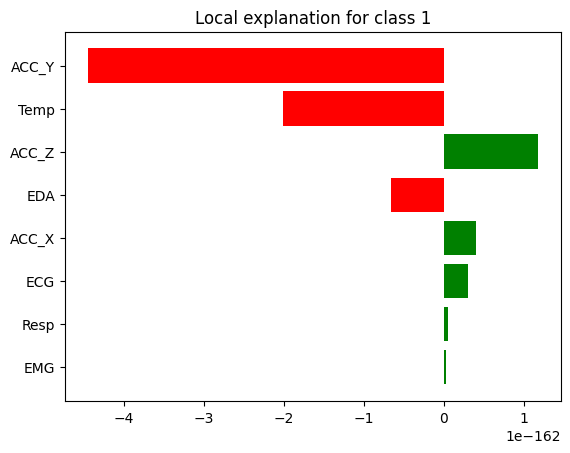

In [29]:
import matplotlib.pyplot as plt

fig = explanation.as_pyplot_figure()
plt.show()

### SHAP

In [40]:
import shap

shap.initjs()

explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test_scaled)

In [41]:
print("X_test_scaled shape:", X_test_scaled.shape)
print("SHAP values shape:", shap_values[1].shape)

X_test_scaled shape: (418600, 8)
SHAP values shape: (8, 2)


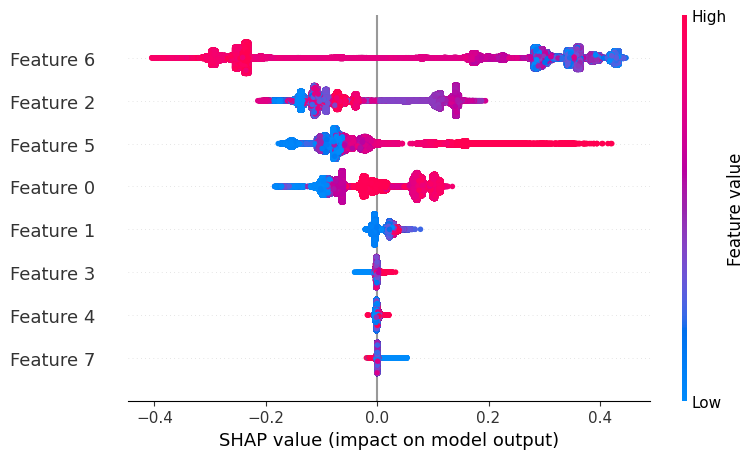

In [42]:
shap.summary_plot(shap_values[:,:,1], X_test_scaled)